In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 # STEP 1 — UPLOADING KAGGLE API KEY 🔑

This cell is crucial for securely uploading your Kaggle API key (`kaggle.json`) to your Colab environment. The `files.upload()` function provides an interactive way to select and upload files directly from your local machine.

**Why is this important?** 🛡️

To access datasets hosted on Kaggle, you need to authenticate your identity using an API key. Uploading it securely ensures that you can download datasets programmatically without exposing your credentials directly in the notebook's code.


In [ ]:
from google.colab import files

files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"imrankhan110","key":"1ebe6a5ad63e21bacc3159dda3b9d9e0"}'}

 # STEP 2 — CONFIGURING KAGGLE ENVIRONMENT ⚙️

This cell sets up the necessary environment for the Kaggle API. It creates a `.kaggle` directory in the root, copies your uploaded `kaggle.json` file into it, and then sets the appropriate file permissions.

**Why is this important?** 🔒

The Kaggle API expects the `kaggle.json` file to be in a specific location (`~/.kaggle/`) and to have strict permissions (`chmod 600`) for security reasons. This step ensures that the API can find your credentials and use them securely to interact with Kaggle.


In [ ]:
import os

# Create Kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# Copy kaggle.json
!cp kaggle.json /root/.kaggle/

# Permission
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle Configured Successfully")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle Configured Successfully


 # STEP 3 — DOWNLOADING THE DATASET FROM KAGGLE ⬇️

This cell uses the Kaggle API to download the `plantdisease` dataset by `emmarex`. The `!kaggle datasets download` command is a convenient way to fetch datasets directly into your Colab environment.

**Why is this important?** 📦

Downloading the dataset is the first practical step in any data-driven project. It provides the raw image data needed for training and evaluating our plant disease detection model. Without this, we would not have the images to process. This step is foundational for our **Computer Vision** task.


In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:08<00:00, 77.0MB/s]



 # STEP 4 — UNZIPPING THE DATASET 📂

This cell unzips the downloaded `plantdisease.zip` file, extracting all the image data into a usable directory structure within the Colab environment. The `!unzip` command handles the decompression.

**Why is this important?** ✨

Datasets downloaded from Kaggle are often compressed to save space and reduce download times. Unzipping them makes the individual image files accessible for further processing, such as loading them into data generators for model training. This step makes the image data ready for **Computer Vision** tasks.


In [ ]:
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [ ]:
!cp -r /content/PlantVillage /content/drive/MyDrive/

 # STEP 5 — INSTALLING REQUIRED LIBRARIES 🛠️

This cell ensures that all necessary Python libraries for the project are installed in the Colab environment. It uses `pip install` to add `tensorflow`, `opencv-python`, and `scikit-fuzzy`.

**Why is this important?** 🚀

These libraries are fundamental for building our plant disease detection system:
*   **`tensorflow`**: For deep learning model development and training.
*   **`opencv-python`**: For image processing tasks.
*   **`scikit-fuzzy`**: For implementing fuzzy logic, which will be used to determine disease severity.

Installing them upfront prevents potential runtime errors and ensures a smooth execution of subsequent steps. This step is crucial for **Deep Learning**, **Computer Vision**, and **Fuzzy Logic** components.


In [ ]:
!pip install tensorflow opencv-python scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.7 MB/s eta 0:00:00


 # STEP 6 — IMPORTING ALL NECESSARY LIBRARIES 📚

This cell imports all the Python libraries and modules that will be used throughout the notebook. It includes components for TensorFlow (deep learning), NumPy (numerical operations), Matplotlib (plotting), OS (path operations), Keras utilities (image data generation, pre-trained models, layers), scikit-fuzzy (fuzzy logic), and multiprocessing (parallel processing).

**Why is this important?** 🧠

Importing libraries at the beginning centralizes all dependencies and makes the code cleaner. It ensures that all necessary functions and classes are available for subsequent steps, allowing for seamless execution of tasks related to **Deep Learning**, **Computer Vision**, **Fuzzy Logic**, and **Parallel Processing**.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from multiprocessing.pool import ThreadPool

 # STEP 7 — DEFINING DATASET PATH AND COUNTING CLASSES 📊

This cell defines the base path to our unzipped dataset and then prints the total number of distinct plant disease classes present in the dataset. It uses the `os.listdir()` function to count the number of subdirectories, each representing a class.

**Why is this important?** 🔍

Knowing the dataset path is essential for correctly loading the images. Counting the classes provides an immediate overview of the problem's complexity and is vital for configuring the output layer of our deep learning model. This step helps in understanding the scope of our **Computer Vision** task.


In [ ]:
dataset_path = "/content/PlantVillage"

print("Total Classes:")

print(len(os.listdir(dataset_path)))

Total Classes:
15


 # STEP 8 — PREPARING IMAGE DATA GENERATORS 🔄

This cell sets up `ImageDataGenerator` objects for both training and validation. These generators handle loading images from directories, rescaling pixel values, and splitting the data into training and validation sets.

**Why is this important?** 🖼️

`ImageDataGenerator` is a powerful tool for efficiently handling large image datasets. It performs data preprocessing (like `rescale=1./255` for normalization) and can apply data augmentation on-the-fly, which helps prevent overfitting. The `validation_split` ensures a standardized separation of data for model evaluation. This is a core component of our **Computer Vision** pipeline for **Deep Learning**.


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


 # STEP 9 — EXTRACTING CLASS NAMES 🏷️

This cell extracts and prints the names of all the disease classes from the `train_data` generator. These class names correspond to the directory names within the dataset.

**Why is this important?** 📋

Knowing the exact class names is crucial for interpreting model predictions. When the model outputs a probability distribution, we map the highest probability to its corresponding class name. This step provides a clear list of what our **Computer Vision** model is learning to identify.


In [ ]:
class_names = list(
    train_data.class_indices.keys()
)

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


 # STEP 10 — DETERMINING THE NUMBER OF CLASSES 🔢

This cell calculates and prints the total number of unique disease classes identified in the dataset. This count is derived from the `class_names` list.

**Why is this important?** 🎯

The number of classes (`num_classes`) is a critical parameter for building the final output layer of our deep learning model. It dictates how many neurons are needed in the final `Dense` layer to predict each class. This is a fundamental setup detail for our **Deep Learning** model in **Computer Vision**.


In [ ]:
num_classes = len(class_names)

print("Total Classes:", num_classes)

Total Classes: 15


 # STEP 11 — LOADING THE PRE-TRAINED MOBILENETV2 BASE MODEL 🧠

This cell loads the MobileNetV2 architecture, pre-trained on the ImageNet dataset. We set `include_top=False` to exclude the original classification head, allowing us to add our custom layers, and define the `input_shape` to match our image dimensions.

**Why is this important?** 🚀

Using a pre-trained model like MobileNetV2 is a powerful technique called **Transfer Learning** in **Deep Learning**. It leverages knowledge gained from a vast dataset (ImageNet) to solve a new, related task (plant disease classification). This significantly reduces training time and often leads to better performance, especially with limited data, as the model already understands basic visual features crucial for **Computer Vision**.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


 # STEP 12 — FREEZING THE BASE MODEL LAYERS 🧊

This cell sets the `trainable` attribute of the `base_model` (MobileNetV2) to `False`. This means that during training, the weights of the pre-trained layers will not be updated.

**Why is this important?** 🔒

Freezing the base model prevents its highly optimized, pre-trained weights from being altered during the initial stages of training on our specific dataset. This is a common practice in **Transfer Learning** within **Deep Learning** to retain the general feature extraction capabilities of the pre-trained network, while only training the newly added classification layers on our specific task, which speeds up training and prevents catastrophic forgetting. This is key for robust **Computer Vision** models.


In [ ]:
base_model.trainable = False

 # STEP 13 — BUILDING THE CUSTOM CLASSIFICATION HEAD 🏗️

This cell constructs our deep learning model by sequentially stacking layers. It starts with the frozen `base_model`, adds a `GlobalAveragePooling2D` layer, a `Dense` layer with ReLU activation, a `Dropout` layer for regularization, and finally, a `Dense` output layer with `softmax` activation for multi-class classification.

**Why is this important?** 🎯

This architecture is designed for **Deep Learning** based **Computer Vision**. The `GlobalAveragePooling2D` layer reduces spatial dimensions while retaining important features. The subsequent `Dense` and `Dropout` layers form the custom classification head, learning to map the extracted features from the base model to our specific `num_classes`. The `softmax` activation provides probability distributions over the classes, indicating the model's confidence for each plant disease.


In [ ]:
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])

 # STEP 14 — COMPILING THE DEEP LEARNING MODEL 🛠️

This cell configures the training process of our deep learning model. It specifies the `optimizer` (`adam`), the `loss` function (`categorical_crossentropy`), and the `metrics` to monitor during training (`accuracy`).

**Why is this important?** ⚙️

Model compilation is a crucial step in **Deep Learning** before training begins.
*   The **Adam optimizer** efficiently adjusts model weights.
*   **Categorical crossentropy** is ideal for multi-class classification problems with one-hot encoded labels.
*   **Accuracy** provides an intuitive measure of the model's performance during training and validation.

These choices directly impact how effectively our **Computer Vision** model learns and performs.


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

 # STEP 15 — DISPLAYING THE MODEL SUMMARY 📝

This cell prints a summary of our entire deep learning model's architecture. This summary includes details about each layer, its output shape, and the number of trainable parameters.

**Why is this important?** 🏗️

The model summary provides a clear overview of our **Deep Learning** model's structure. It helps in understanding the flow of data through the layers, verifying the output shapes, and identifying the total number of parameters (both trainable and non-trainable). This information is valuable for debugging, optimizing, and ensuring the model is built as intended for our **Computer Vision** task.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 # STEP 16 — TRAINING THE DEEP LEARNING MODEL 🚀

This cell initiates the training process of our compiled deep learning model using the prepared `train_data` and `val_data` generators. The model is trained for 5 `epochs`.

**Why is this important?** 🎓

This is where our **Deep Learning** model learns to identify plant diseases from images. During each epoch, the model processes the entire training dataset, adjusts its internal weights to minimize the loss function, and evaluates its performance on the validation set. This iterative learning process is fundamental to developing a high-performing **Computer Vision** system for plant disease detection.


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 88s 132ms/step - accuracy: 0.7682 - loss: 0.7337 - val_accuracy: 0.8775 - val_loss: 0.3796
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.8702 - loss: 0.3935 - val_accuracy: 0.8928 - val_loss: 0.3193
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.8965 - loss: 0.3084 - val_accuracy: 0.9088 - val_loss: 0.2661
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.9117 - loss: 0.2629 - val_accuracy: 0.9032 - val_loss: 0.2790
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - accuracy: 0.9248 - loss: 0.2229 - val_accuracy: 0.9207 - val_loss: 0.2335


 # STEP 17 — SAVING THE TRAINED MODEL 💾

This cell saves the trained deep learning model to a file named `plant_disease_model.h5`. This allows us to store the model's architecture, weights, and optimizer state.

**Why is this important?** ✅

Saving the trained model is crucial for persistence. Once trained, we can load this model later without needing to retrain it, saving significant computational resources and time. This makes the **Deep Learning** model ready for deployment or further evaluation on new, unseen **Computer Vision** data.


In [ ]:
model.save('/content/drive/MyDrive/plant_disease_model.h5')
print("Model Saved Successfully")

Model Saved Successfully


 # STEP 18 — VISUALIZING MODEL ACCURACY 📈

This cell generates and displays a line plot showing the training accuracy and validation accuracy over the epochs. It helps in understanding how well the **Deep Learning** model is learning and generalizing.

**Why is this important?** 🧐

Visualizing accuracy is vital for monitoring the training process of our **Computer Vision** model. It helps identify:
*   **Underfitting**: If both accuracies are low.
*   **Overfitting**: If training accuracy is high but validation accuracy is significantly lower and decreases.
*   **Good Fit**: If both accuracies increase and stabilize at a high value.

This plot provides insights into the model's performance and generalization capabilities.


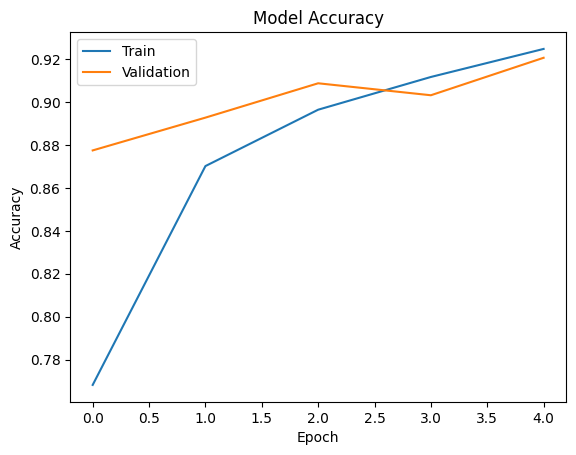

In [ ]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

 # STEP 19 — VISUALIZING MODEL LOSS 📉

This cell generates and displays a line plot showing the training loss and validation loss over the epochs. It helps in understanding the optimization process of the deep learning model.

**Why is this important?** 📉

Plotting the loss curves is essential for debugging and fine-tuning our **Deep Learning** model for **Computer Vision**. A decreasing loss indicates that the model is learning. Divergence between training and validation loss often signals overfitting, while high and stagnant loss suggests underfitting. Analyzing these curves helps ensure that the model is converging correctly and effectively minimizing errors.


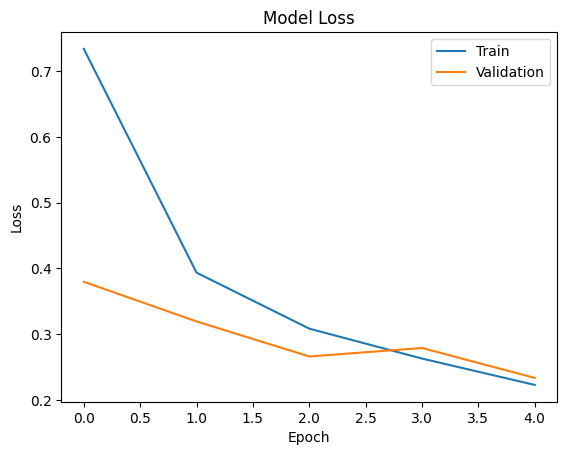

In [ ]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

 # STEP 20 — UPLOADING TEST IMAGES ⬆️

This cell uses `files.upload()` to allow you to interactively select and upload new images from your local machine. These images will be used to test the trained plant disease detection model.

**Why is this important?** 🧪

To evaluate the real-world performance of our **Computer Vision** model, we need to test it on unseen data. Uploading images provides a convenient way to feed new plant leaf photos into the model and observe its predictions. This step simulates how the model would be used in a practical application.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving images (1).jpeg to images (1).jpeg
Saving 2_5.jpg to 2_5.jpg
Saving dataset-card.jpg to dataset-card.jpg


 # STEP 21 — LISTING UPLOADED IMAGES 🖼️

This cell retrieves the filenames of the images that were just uploaded using `files.upload()` and stores them in `image_list`. It then prints this list.

**Why is this important?** 📍

Having a list of uploaded image filenames is necessary to iterate through them and process each image with our trained **Computer Vision** model. This step confirms which images are available for prediction and prepares them for the next stage of individual processing.


In [ ]:
image_list = list(uploaded.keys())

print(image_list)

['images (1).jpeg', '2_5.jpg', 'dataset-card.jpg']


 # STEP 22 — DEFINING THE IMAGE PROCESSING AND PREDICTION FUNCTION 🤖

This cell defines a Python function `process_image` that takes an image file path, loads and preprocesses the image, feeds it to the trained deep learning model for prediction, and returns the predicted class and confidence. This function encapsulates the core **Computer Vision** inference logic.

**Why is this important?** ⚙️

This function centralizes the steps required to get a prediction from a single image. It ensures consistent preprocessing (resizing, normalization) and efficient model inference. By packaging these operations into a function, we can easily apply it to multiple images, making the prediction process modular and reusable.


In [ ]:
def process_image(img_path):

    # Load image
    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    # Convert image
    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Prediction
    prediction = model.predict(
        img_array,
        verbose=0
    )

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    # Result
    result = {
        "Image": img_path,
        "Prediction": class_names[predicted_class],
        "Confidence": round(confidence,2)
    }

    return result

 # STEP 23 — PARALLEL IMAGE PROCESSING FOR PREDICTIONS 🚀

This cell utilizes a `ThreadPool` to apply the `process_image` function to all uploaded images in `image_list` concurrently. This allows for parallel execution of image predictions.

**Why is this important?** ⚡

When dealing with multiple images, processing them sequentially can be time-consuming. **Parallel Processing** significantly speeds up inference by distributing the workload across multiple threads. This efficiency is critical for real-time or batch processing applications where quick predictions are desired for **Computer Vision** tasks.


In [ ]:
pool = ThreadPool(processes=2)

results = pool.map(
    process_image,
    image_list
)

pool.close()
pool.join()

 # STEP 24 — DISPLAYING PREDICTION RESULTS ✨

This cell iterates through the `results` obtained from the parallel processing and prints the prediction, confidence level, and the name of the image for each uploaded test image. It provides a clear, itemized output for each prediction.

**Why is this important?** 📊

Displaying the prediction results in an organized manner is essential for understanding what our **Computer Vision** model has identified for each image. This step gives immediate feedback on the model's performance and allows for quick verification of the predicted disease and its associated confidence, which will then be fed into our **Fuzzy Logic** system.


In [ ]:
for r in results:

    print("Image:", r["Image"])

    print("Prediction:", r["Prediction"])

    print("Confidence:", r["Confidence"], "%")

    print("-"*50)

Image: images (1).jpeg
Prediction: Tomato__Tomato_YellowLeaf__Curl_Virus
Confidence: 90.82 %
--------------------------------------------------
Image: 2_5.jpg
Prediction: Pepper__bell___Bacterial_spot
Confidence: 90.33 %
--------------------------------------------------
Image: dataset-card.jpg
Prediction: Potato___Late_blight
Confidence: 94.86 %
--------------------------------------------------


 # STEP 25 — DEFINING FUZZY LOGIC ANTECEDENTS AND CONSEQUENTS 💡

This cell initializes the antecedent (input) and consequent (output) variables for our **Fuzzy Logic** control system. `confidence_input` represents the model's prediction confidence, and `severity_output` will represent the calculated disease severity.

**Why is this important?** ⚖️

In **Fuzzy Logic**, antecedents and consequents are the building blocks of fuzzy rules. By defining these variables and their universes (ranges), we establish the linguistic terms (like 'low', 'medium', 'high') that will be used to describe them, allowing us to translate numerical confidence scores into a qualitative measure of severity. This prepares the system for inferring disease severity from the **Computer Vision** model's output.


In [ ]:
confidence_input = ctrl.Antecedent(
    np.arange(0,101,1),
    'confidence'
)

severity_output = ctrl.Consequent(
    np.arange(0,101,1),
    'severity'
)

 # STEP 26 — DEFINING FUZZY MEMBERSHIP FUNCTIONS 🌊

This cell defines the membership functions for both the `confidence_input` and `severity_output` variables. Triangular membership functions (`fuzz.trimf`) are used to represent linguistic terms like 'low', 'medium', and 'high' for each variable.

**Why is this important?** 📊

Membership functions are central to **Fuzzy Logic**. They quantify the degree to which a crisp (numerical) value belongs to a fuzzy set (e.g., how 'low' a confidence of 40% is). These functions allow the fuzzy system to interpret the numerical confidence from our **Computer Vision** model and translate it into meaningful fuzzy linguistic terms, which are then used in the fuzzy rules to determine disease severity.


In [ ]:
confidence_input['low'] = fuzz.trimf(
    confidence_input.universe,
    [0,0,50]
)

confidence_input['medium'] = fuzz.trimf(
    confidence_input.universe,
    [30,50,80]
)

confidence_input['high'] = fuzz.trimf(
    confidence_input.universe,
    [60,100,100]
)

severity_output['low'] = fuzz.trimf(
    severity_output.universe,
    [0,0,50]
)

severity_output['medium'] = fuzz.trimf(
    severity_output.universe,
    [30,50,80]
)

severity_output['high'] = fuzz.trimf(
    severity_output.universe,
    [60,100,100]
)

 # STEP 27 — DEFINING FUZZY LOGIC RULES ⚖️

This cell establishes the core logic of our **Fuzzy Logic** system by defining three rules (`rule1`, `rule2`, `rule3`). These rules link the `confidence_input` (low, medium, high) to the corresponding `severity_output` (low, medium, high).

**Why is this important?** 📜

Fuzzy rules are IF-THEN statements that capture human-like reasoning. They provide a clear, interpretable way to infer the severity of a disease based on the model's confidence. For example, IF confidence is HIGH, THEN severity is HIGH. These rules enable our system to make qualitative decisions based on the quantitative output of our **Computer Vision** model.


In [ ]:
rule1 = ctrl.Rule(
    confidence_input['low'],
    severity_output['low']
)

rule2 = ctrl.Rule(
    confidence_input['medium'],
    severity_output['medium']
)

rule3 = ctrl.Rule(
    confidence_input['high'],
    severity_output['high']
)

 # STEP 28 — CREATING THE FUZZY CONTROL SYSTEM 🧠

This cell constructs the `ControlSystem` and `ControlSystemSimulation` objects using the previously defined fuzzy rules. The `ControlSystem` holds all the rules, and `ControlSystemSimulation` is used to run the fuzzy inference process.

**Why is this important?** 🔬

This step brings together all the components of our **Fuzzy Logic** system. The `ControlSystem` acts as the brain, encapsulating the decision-making logic. The `ControlSystemSimulation` is the engine that allows us to input a crisp value (model confidence) and get a crisp output (disease severity) by applying the fuzzy rules, fuzzification, inference, and defuzzification processes. This bridges the **Computer Vision** model's prediction with an actionable severity assessment.


In [ ]:
severity_ctrl = ctrl.ControlSystem(
    [rule1, rule2, rule3]
)

severity_simulation = ctrl.ControlSystemSimulation(
    severity_ctrl
)

 # STEP 29 — CALCULATING AND DISPLAYING FUZZY SEVERITY SCORES 🌟

This cell iterates through the prediction results, applies the **Fuzzy Logic** system to each confidence score to calculate a `severity_value`, and then assigns a qualitative `level` (LOW, MEDIUM, HIGH) based on this value. Finally, it displays each processed image along with its prediction, confidence, and the calculated severity level.

**Why is this important?** 💡

This is the culmination of our **Computer Vision** and **Fuzzy Logic** integration. It demonstrates how the numerical confidence from the deep learning model is transformed into a more human-understandable severity assessment. Visualizing the images with these enhanced labels provides comprehensive feedback, combining the power of image recognition with intelligent decision-making, offering a more complete diagnosis for plant health.


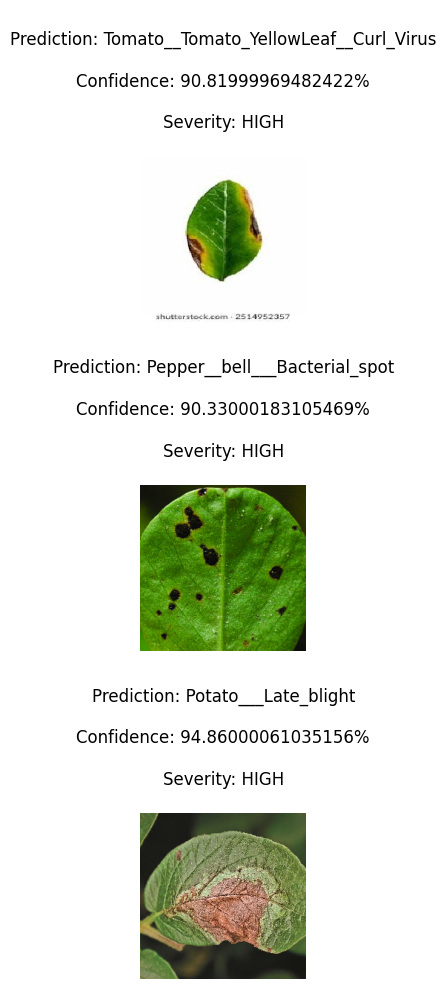

In [ ]:
severity_scores = []

plt.figure(figsize=(15,10))

for i, r in enumerate(results):

    # Fuzzy Logic
    severity_simulation.input['confidence'] = r["Confidence"]

    severity_simulation.compute()

    severity_value = severity_simulation.output['severity']

    severity_scores.append(severity_value)

    # Severity Label
    if severity_value < 40:
        level = "LOW"

    elif severity_value < 70:
        level = "MEDIUM"

    else:
        level = "HIGH"

    # Load image
    img = image.load_img(r["Image"], target_size=(224,224))

    # Plot image
    plt.subplot(
        len(results),
        1,
        i+1
    )

    plt.imshow(img)

    plt.axis("off")

    # Title
    plt.title(f"""
Prediction: {r['Prediction']}

Confidence: {r['Confidence']}%

Severity: {level}
""")

plt.tight_layout()

plt.show()

 # STEP 30 — VISUALIZING DISEASE PREDICTION CONFIDENCE (BAR CHART) 📊

This cell generates a bar chart that displays the confidence level for each predicted disease. The diseases are plotted on the x-axis, and their corresponding confidence percentages are on the y-axis.

**Why is this important?** 📈

Visualizing confidence levels with a bar chart provides a clear and intuitive way to compare how strongly the **Computer Vision** model predicts each disease. It helps in quickly identifying the primary predicted disease and understanding the model's certainty, which is a key output of our **Deep Learning** system.


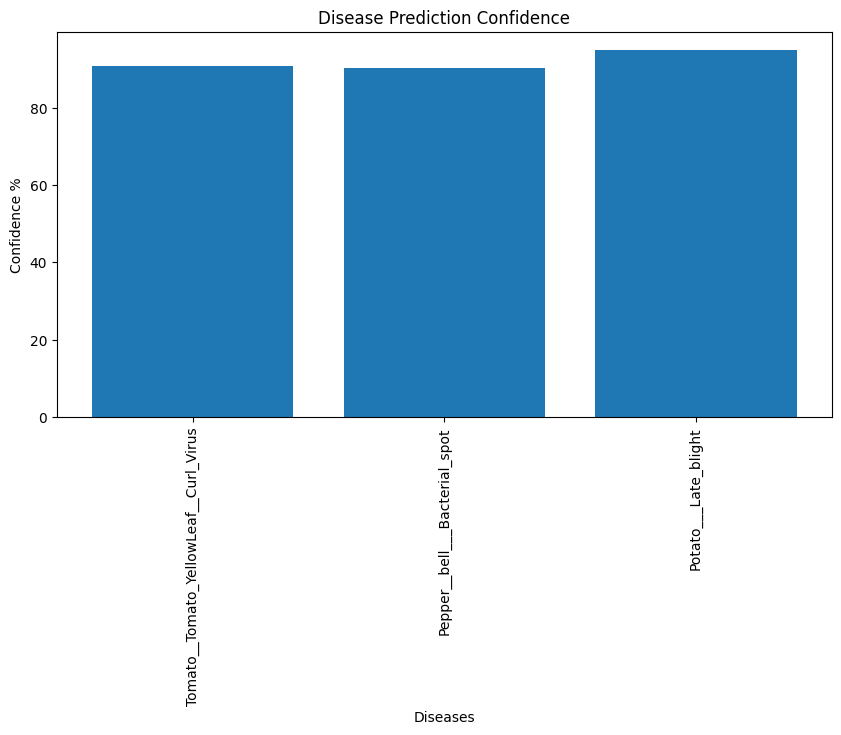

In [ ]:
diseases = [r["Prediction"] for r in results]

confidences = [r["Confidence"] for r in results]

plt.figure(figsize=(10,5))

plt.bar(diseases, confidences)

plt.title("Disease Prediction Confidence")

plt.xlabel("Diseases")

plt.ylabel("Confidence %")

plt.xticks(rotation=90)

plt.show()

 # STEP 31 — VISUALIZING DISEASE DISTRIBUTION (PIE CHART) 🥧

This cell generates a pie chart that illustrates the distribution of predicted diseases based on their confidence scores. Each slice represents a disease, and its size corresponds to its confidence percentage relative to the sum of all confidences.

**Why is this important?** 📉

The pie chart offers an alternative visualization to understand the proportional distribution of the **Computer Vision** model's predictions. While a bar chart shows individual confidences, a pie chart emphasizes the contribution of each disease prediction to the overall diagnostic picture, providing a quick summary of the most prevalent diseases identified in the test images. This is another effective way to present the results of our **Deep Learning** model.


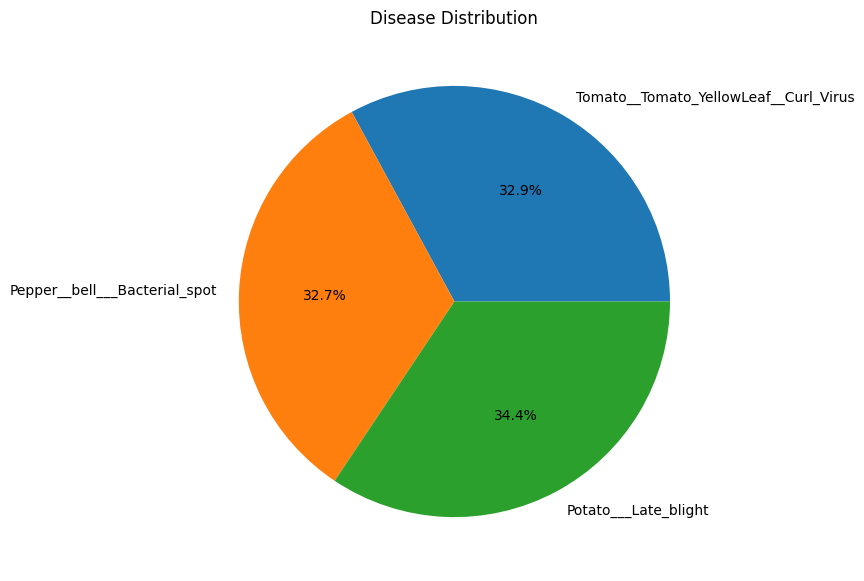

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(
    confidences,
    labels=diseases,
    autopct='%1.1f%%'
)

plt.title("Disease Distribution")

plt.show()